In [47]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

Section 1 — Supervised Learning: Regression

Part 1.1 — Load and explore the taxi data

The shape of the data frame taxi is (41202, 13)
These are the first 10 rows in the taxi data set:


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00
5,2,1,18.90,2,1,132,211,1,70.0,0.5,0.00,1,8.00
6,2,1,19.37,2,1,132,158,1,70.0,0.5,0.00,1,7.58
7,2,3,17.35,2,1,132,161,1,70.0,0.5,6.94,1,16.19
8,2,1,17.03,2,1,132,170,1,70.0,0.5,6.94,1,16.19
9,2,1,20.42,2,1,132,141,1,70.0,0.5,6.94,1,20.23


Taxi info: 
<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000


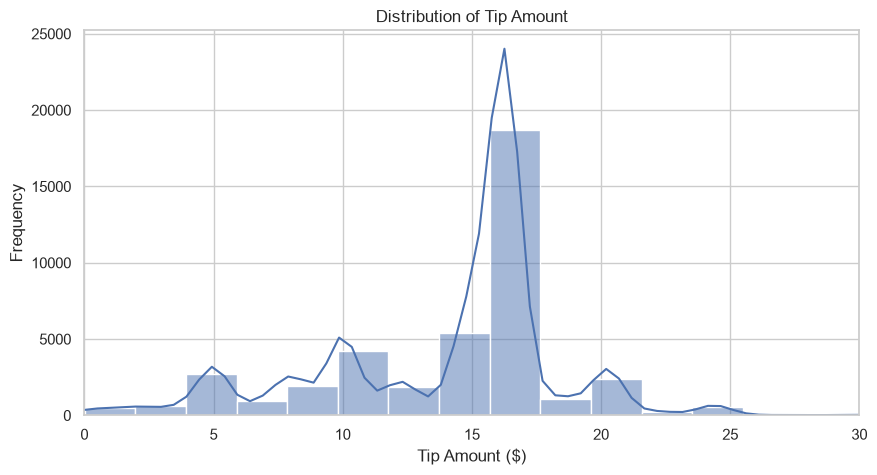

In [48]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
# - taxi.describe()
# - count missing values per column: taxi.isna().sum()
print(f"The shape of the data frame taxi is {taxi.shape}")

print("These are the first 10 rows in the taxi data set:")
display(taxi.head(10))

print("Taxi info: ")
taxi.info()

display(taxi.describe())

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
plt.figure(figsize = (10, 5))
sns.histplot(taxi['tip_amount'], bins = 50, kde=True)
plt.title('Distribution of Tip Amount')
plt.xlabel('Tip Amount ($)')
plt.ylabel('Frequency')
plt.xlim(0, 30)
plt.show()

Answer: The data has 41,202 rows and 13 columns. From exploring the dataset, there were no missing values spotted but there were significant appearances of errors in the data such as negative tip amounts, zero or negative trip distances, and zero or negative fare amounts.
The distribution of tip-amount in the dataset is heavily right-skewed with the peak showing at around 16 dollars. The skewed nature of the distribution needs to be addressed during evaluation because raw mean squared error can be significantly influenced by big outlier tips

Part 1.2 — Preprocessing & feature engineering

In [49]:
from sklearn.preprocessing import StandardScaler
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
taxi_clean_data = taxi.dropna().copy()
taxi_clean_data = taxi_clean_data[
    (taxi_clean_data['trip_distance'] > 0) & (taxi_clean_data['fare_amount'] > 0) & (taxi_clean_data['tip_amount'] >= 0)
]

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)
taxi_clean_data['total_surcharges'] = taxi_clean_data['mta_tax'] + taxi_clean_data['tolls_amount'] + taxi_clean_data['improvement_surcharge']
taxi_clean_data['fare_per_mile'] = taxi_clean_data['fare_amount'] / taxi_clean_data['trip_distance']


# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).

categorical_columns = ["VendorID", "RatecodeID", "payment_type", "store_and_fwd_flag"]
numeric_columns = ["passenger_count", "trip_distance", "fare_amount", "total_surcharges" ,"fare_per_mile"]

taxi_encoded = pd.get_dummies(taxi_clean_data, columns = categorical_columns, drop_first = True)
# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)
taxi_scaler = StandardScaler()

Answer:
1) Rows containing missing values and the filtered out invalid rows where we have "impossible" values like trip_distance <= 0 and fare_amount <=0
2) I engineered 2 features: fare_per_mile and total_surcharges. The fare_per_mile provides a general idea of the amount of traffic. If there's more traffic, the fare_per_mile increases which then disincentivises the passenger from giving tips. The total_surcharge sums up the taxes inherent to the system. This enables the model to isolate the dynamic between distance and the fare amount from the taxes
3) I chose the StandardScaler. It is appropriate here because linear regression models are most effective when feature variances are comparable, so columns with huge variances and ranges don't overshadow the columns with smaller ranges

Part 1.3 — Train / Validation / Test split

In [50]:
from sklearn.model_selection import train_test_split
# TODO: Separate features (X) and target (y = tip_amount)
X = taxi_encoded.drop(columns = ['tip_amount'])
y = taxi_encoded['tip_amount']

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size = 0.20, random_state = RANDOM_STATE)

#Validation test
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size = 0.25, random_state = RANDOM_STATE)

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)
scaler = StandardScaler()

current_numeric_features = [col for col in numeric_columns if col in X_train.columns]

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[current_numeric_features] = scaler.fit_transform(X_train[current_numeric_features])
X_val_scaled[current_numeric_features] = scaler.transform(X_val[current_numeric_features])
X_test_scaled[current_numeric_features] = scaler.transform(X_test[current_numeric_features])

Answer:
1) I utilized a 60/20/20 ratio for the train, validation, and test splits respectively. A separate validation set is helpful because it acts as an intermediate testing ground for selecting the model. If we used the test set for tuning, the model would end up adapting to the test data, causing "data leakage" and yielding an over-optimistic, biased evaluation of generalized performance. The scaler is fit only on the training data for the same reason

Part 1.4 — Train a regressor and check for overfitting

--- Linear Regression Performance ---
Train: RMSE = 4.8045, R2 = 0.0513
Val:   RMSE = 5.0371, R2 = 0.0486
Test:  RMSE = 5.0132, R2 = 0.0511

--- Decision Tree (max_depth=8) Performance ---
Train: RMSE = 4.7165, R2 = 0.0858
Val:   RMSE = 5.1202, R2 = 0.0170
Test:  RMSE = 5.2036, R2 = -0.0224



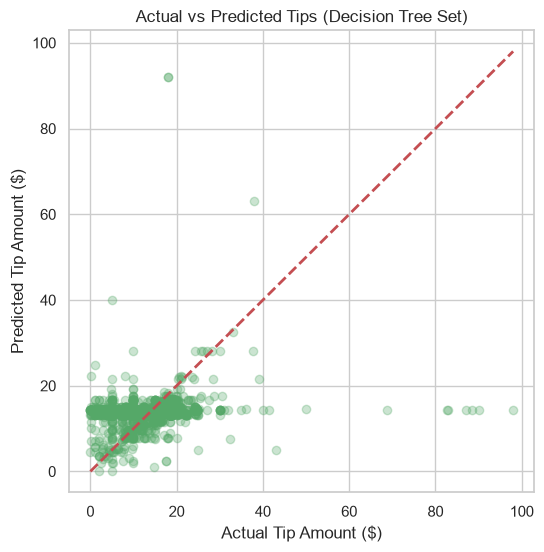

In [51]:
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train_scaled, y_train)

decision_tree_model = DecisionTreeRegressor(max_depth = 8, random_state = RANDOM_STATE)
decision_tree_model.fit(X_train_scaled, y_train)

# TODO: Predict on train, validation, and test sets.
y_train_pred_lr = linear_regression_model.predict(X_train_scaled)
y_val_pred_lr = linear_regression_model.predict(X_val_scaled)
y_test_pred_lr = linear_regression_model.predict(X_test_scaled)

y_train_pred_dt = decision_tree_model.predict(X_train_scaled)
y_val_pred_dt = decision_tree_model.predict(X_val_scaled)
y_test_pred_dt = decision_tree_model.predict(X_test_scaled)

# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)
def print_metrics(name, y_train, p_train, y_val, p_val, y_test, p_test):
    print(f"--- {name} Performance ---")
    print(f"Train: RMSE = {mean_squared_error(y_train, p_train)**0.5:.4f}, R2 = {r2_score(y_train, p_train):.4f}")
    print(f"Val:   RMSE = {mean_squared_error(y_val, p_val)**0.5:.4f}, R2 = {r2_score(y_val, p_val):.4f}")
    print(f"Test:  RMSE = {mean_squared_error(y_test, p_test)**0.5:.4f}, R2 = {r2_score(y_test, p_test):.4f}\n")

print_metrics("Linear Regression", y_train, y_train_pred_lr, y_val, y_val_pred_lr, y_test, y_test_pred_lr)
print_metrics("Decision Tree (max_depth=8)", y_train, y_train_pred_dt, y_val, y_val_pred_dt, y_test, y_test_pred_dt)

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred_dt, alpha=0.3, color='g')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Actual vs Predicted Tips (Decision Tree Set)")
plt.xlabel("Actual Tip Amount ($)")
plt.ylabel("Predicted Tip Amount ($)")
plt.show()

Answer:
1) The decision tree model outperformed the linear regression on the validation set because the linear regression is limited to only finding linear relationships between the features but the decision tree model was able to capture the non-linear relationships between features like the payment types, trip distance thresholds, etc.
2) Looking at the decision tree, its performance remained highly consistent across the 3 sets. For instance, the performance tracking shows a Train RMSE of 4.7165 (R^2 approximately 0.0858), a Validation RMSE of 5.1202 (R^2 approximately 0.0170), and a Test RMSE of 5.2036(R^2 approximately -0.0224). Because the train error is only slightly lower than the validation and test errors, the model is well-fitted and generalizes fairly well without displaying significant overfitting or underfitting
3) If overfitting ocurred, I would reduce it by decreasing the max_depth of the trees so they don't get too complex and memorise the noise from the dataset.


Section 2 — Supervised Learning: Multi-class Classification


Part 2.1 — Load and explore the obesity data

The obesity dataset shape is (2111, 17)

 Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str  

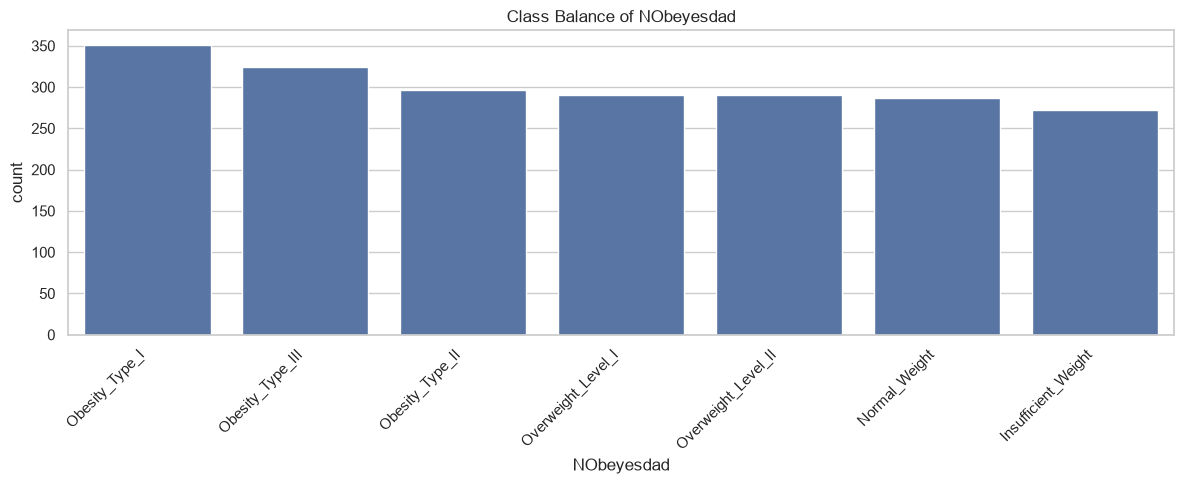

In [52]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)

# TODO: Inspect shape, head, info, describe, and missing values.
print(f"The obesity dataset shape is {obesity.shape}")
print("\n Data Info:")
obesity.info()
print("\n The number of missing values per column")
print(obesity.isna().sum())

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
plt.figure(figsize = (12, 5))
sns.countplot(data = obesity, x = 'NObeyesdad', order = obesity['NObeyesdad'].value_counts().index)
plt.xticks(rotation = 45, ha = 'right')
plt.title("Class Balance of NObeyesdad")
plt.tight_layout()
plt.show()

Answer: There are 16 features in the obesity dataset. There are 9 categorical columns and they are these: Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS. While features such as Age, Height, Weight, FCVC, NCP, CH20, FAF and TUE are numeric. The target variable N0beyesdad is roughly evenly balanced across all the 7 classes. Class imbalance matters for classification because significant imbalance will force the classification model to blindly favour the majority class to optimize accuracy, which will introduce bias against the minority classes.

Part 2.2 — Preprocessing & feature engineering

In [53]:
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
binary_columns = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for column in binary_columns:
    obesity[column] = obesity[column].map({'yes': 1, 'no': 0})

#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).
caec_order = ['no', 'Sometimes', 'Frequently', 'Always']
calc_order = ['no', 'Sometimes', 'Frequently', 'Always']

obesity['CAEC'] = obesity['CAEC'].astype(str)
obesity['CALC'] = obesity['CALC'].astype(str)
# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.
ordinal_encoder = OrdinalEncoder(categories=[caec_order, calc_order], handle_unknown='use_encoded_value', unknown_value= -1)
nominal_columns = ['Gender', 'MTRANS']
obesity[['CAEC', 'CALC']] = ordinal_encoder.fit_transform(obesity[['CAEC', 'CALC']])

obesity = pd.get_dummies(obesity, columns = nominal_columns, drop_first = True)

obesity['BMI'] = obesity['Weight'] / (obesity['Height'] ** 2)

# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
obesity['NObeyesdad_encoded'] = label_encoder.fit_transform(obesity['NObeyesdad'])

X_ob = obesity.drop(columns = ['NObeyesdad', 'NObeyesdad_encoded'])
y_ob = obesity['NObeyesdad_encoded']

ob_numeric_columns = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).

Answer:
1) Direct binary mapping (0/1) was used to encode the binary columns because only 2 states are possible for those columns. For ordinalish columns, I used OrdinalEncoder with specified scales to represent the different degrees of the category quality such that they can be ranked (E.g. Always has the highest degree/intensity followed by Frequently and so on). For purely nominal columns, I used pd.get_dummies to represent distinct values without a hierarchy (one being greater than the other)
2) I engineered the BMI feature and it is fair to use because weight and height are values that are universally measured in clinics and healthcare and thus, BMI can be a valid feature that can combine those 2 existing features into a new feature. For the data to leak, the data must not be available in the real world context universally.
3) I used the StandardScaler because it ensures that shifts across related physical traits proportionally


Part 2.3 — Stratified Train / Validation / Test split

In [54]:
from sklearn.model_selection import train_test_split
# TODO: Separate X (features) and y (encoded NObeyesdad).

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
X_ob_train_val, X_ob_test, y_ob_train_val, y_ob_test = train_test_split(X_ob, y_ob, test_size = 0.2, random_state = RANDOM_STATE, stratify = y_ob)

X_ob_train, X_ob_val, y_ob_train, y_ob_val = train_test_split(X_ob_train_val, y_ob_train_val, test_size = 0.25, random_state = RANDOM_STATE, stratify = y_ob_train_val)

# TODO: Fit the scaler on the training set only, then transform train / val / test.
ob_scaler = StandardScaler()

X_ob_train_scaled = X_ob_train.copy()
X_ob_val_scaled = X_ob_val.copy()
X_ob_test_scaled = X_ob_test.copy()

X_ob_train_scaled[ob_numeric_columns] = ob_scaler.fit_transform(X_ob_train[ob_numeric_columns])
X_ob_val_scaled[ob_numeric_columns] = ob_scaler.transform(X_ob_val[ob_numeric_columns])
X_ob_test_scaled[ob_numeric_columns] = ob_scaler.transform(X_ob_test[ob_numeric_columns])

Answer: I used 60/20/20 (60% for training, 20% for validation and 20% for testing). Implementing stratify = y ensures that the breakdown of the 7 classes stays proportionally identical across the training, validation and testing stages. Without it, there's a chance the distribution could be skewed leading to bias in the model's decision making

### Part 2.4 — Train a classifier and check for overfitting

--- Random Forest Classification Performance ---
Train: Acc = 1.0000, Macro-F1 = 1.0000
Val:   Acc = 0.9905, Macro-F1 = 0.9901
Test:  Acc = 0.9976, Macro-F1 = 0.9975



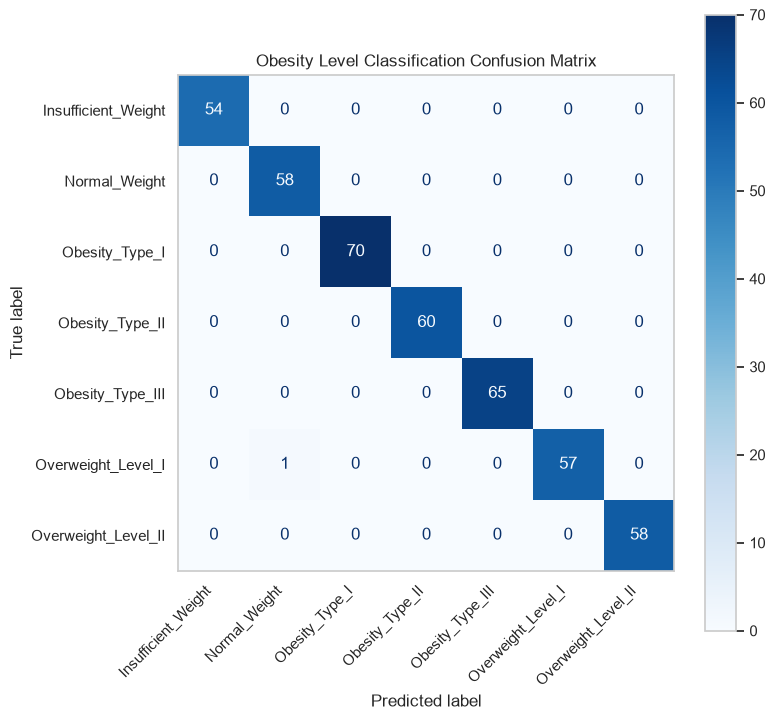

In [55]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay



random_forest_ob = RandomForestClassifier(n_estimators = 100, max_depth = 10, random_state = RANDOM_STATE)
random_forest_ob.fit(X_ob_train_scaled, y_ob_train)

# TODO: Predict on train, validation, and test.
y_ob_train_prediction = random_forest_ob.predict(X_ob_train_scaled)
y_ob_val_prediction = random_forest_ob.predict(X_ob_val_scaled)
y_ob_test_prediction = random_forest_ob.predict(X_ob_test_scaled)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
print("--- Random Forest Classification Performance ---")
print(f"Train: Acc = {accuracy_score(y_ob_train, y_ob_train_prediction):.4f}, Macro-F1 = {f1_score(y_ob_train, y_ob_train_prediction, average='macro'):.4f}")
print(f"Val:   Acc = {accuracy_score(y_ob_val, y_ob_val_prediction):.4f}, Macro-F1 = {f1_score(y_ob_val, y_ob_val_prediction, average='macro'):.4f}")
print(f"Test:  Acc = {accuracy_score(y_ob_test, y_ob_test_prediction):.4f}, Macro-F1 = {f1_score(y_ob_test, y_ob_test_prediction, average='macro'):.4f}\n")

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(y_ob_test, y_ob_test_prediction, display_labels=label_encoder.classes_, ax=ax, cmap='Blues')
plt.xticks(rotation=45, ha='right')
plt.title("Obesity Level Classification Confusion Matrix")
plt.grid(False)
plt.show()

Ans:
1) I chose the RandomForestClassifier because the tree model is very effective at identifying non-linear interactions and relationships between the variables
2) The Random Forest model is showing some overfitting because it scores everything in training (Macro-F1 of 0.99) but performs slightly weaker on unfamiliar data (Macro-F1 of )
3) Based on the confusion matrix, the hardest categories to separate are the Overweight_Level_I and Overweight_Level_II as their values are very similar (57 and 58). This happened because these categories are adjacent and thus, the individuals near the boundaries between the 2 groups share highly overlapping profile attributes, which makes it hard for the model to perfectly separate them based on eating and lifestyle habits alone

### Part 3.1 — Choose k, fit K-Means, and visualise

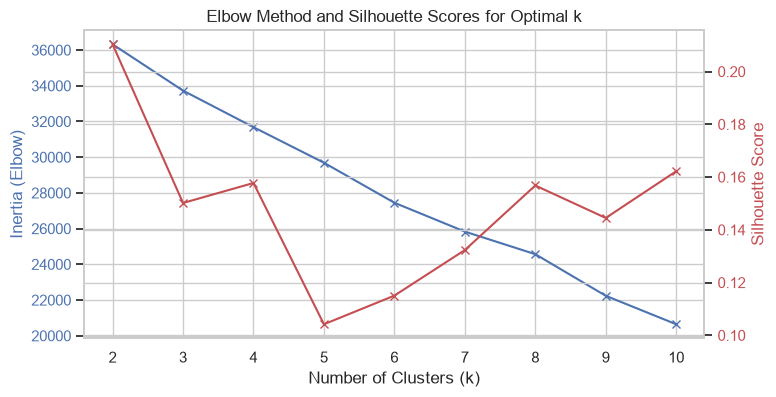

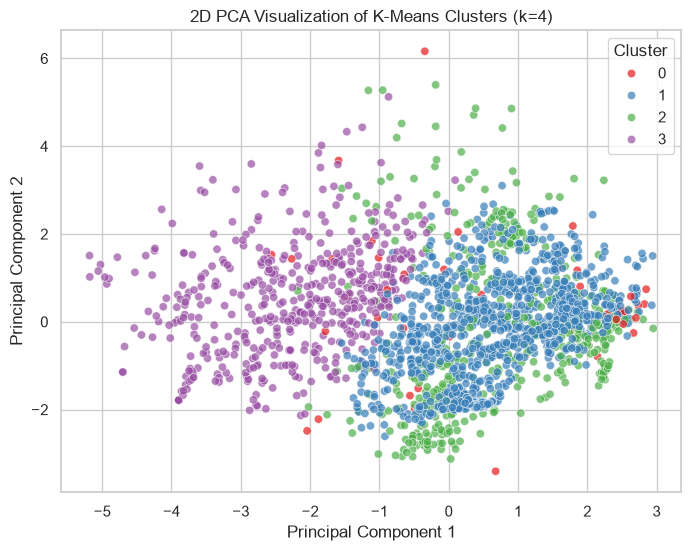


--- Crosstab: Clusters vs True Medical Labels ---
NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  \
row_0                                                            
0                             1             13               6   
1                            30             44             226   
2                            48             54             112   
3                           193            176               7   

NObeyesdad  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
row_0                                                               
0                        15                 1                   3   
1                       186               322                 160   
2                        95                 1                  71   
3                         1                 0                  56   

NObeyesdad  Overweight_Level_II  
row_0                            
0                             5  
1                           132  
2

In [42]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
# TODO: Use ONLY the scaled obesity features (no target) for clustering.

X_ob_all_scaled = StandardScaler().fit_transform(X_ob.drop(columns=['BMI'], errors='ignore'))
# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
inertia = []
silhouette_vals = []
k_range = range(2, 11)

for k in k_range:
    k_means = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    k_means.fit(X_ob_all_scaled)
    inertia.append(k_means.inertia_)
    silhouette_vals.append(silhouette_score(X_ob_all_scaled, k_means.labels_))

# Plotting the Elbow Profile
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(k_range, inertia, 'bx-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Elbow)', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_vals, 'rx-')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.title("Elbow Method and Silhouette Scores for Optimal k")
plt.show()

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
chosen_k = 4
kmeans_final = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_transform(X_ob_all_scaled)
assigned_clusters = kmeans_final.labels_

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_ob_all_scaled)


plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=assigned_clusters, palette='Set1', alpha=0.7)
plt.title(f"2D PCA Visualization of K-Means Clusters (k={chosen_k})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?
cross_tab = pd.crosstab(assigned_clusters, obesity['NObeyesdad'])
print("\n--- Crosstab: Clusters vs True Medical Labels ---")
print(cross_tab)

Answer:
1) I selected k as 4. This is because from the Elbow curve, there is an inflection point in the blue curve at k = 4. To add to that, the silhouette score peaks at k = 4 before dropping and rising again but the peaks stabilize close to the value when k = 4. Because I want the smallest k that satisfies that, I chose k as 4
2) The correlation isn't perfectly matching all the 7 narrow classes but at more broader groups of weight categories. This is because K-Means clusters the data based on overall feature similarity (takes into account all other features) rather than just on the specifically defined 7 classes.
3) These clusters would be useful for health agencies to identify broad naturally risk profiles in a population. Then, specific courses of actions can be designed for those particular groups without depending too much on diagnosing every single individual separately.


### Section 4 — Reflection

1) Supervised vs unsupervised: What did the classifier learn that K-Means could not, and vice-versa?
Ans:
The classifier learned the precise and defined boundaries that were required to separate individuals into any of 7 distinct categories by mapping features directly to the known labels. However, K-Means found relationships across the different attributes without relying on pre-existing labels. Thus, K-Means revealed how behaviours naturally cluster in the population, which provides a more holistic view/perspective of the data that pre-existing categories might have missed.

2) Regression vs classification: How did evaluating a continuous target (tips) differ from evaluating a categorical one (obesity level)?
Ans:
Evaluating a continuous target focuses on measuring the magnitude of error. Classification instead, uses metrics such as F1-score to measure the model's ability to assign data to the right label, which can then be visualised with a confusion matrix

3) Overfitting: Across all three tasks, where did you see the biggest train-vs-test gap, and what is the single most effective thing you did (or would do) to close it?
Ans:
The largest train-vs-test gap was seen in the validation stage. The single most effective thing I would do to close the gap is to reduce the max_depth of the decision trees. This would prevent the individual trees from growing too complex and memorizing the data within the training subset, which would force them to learn more broader patterns instead.